# Method 2: Probabilistic Hough Transform
Uses `cv2.HoughLinesP` to detect finite line segments with start/end points.

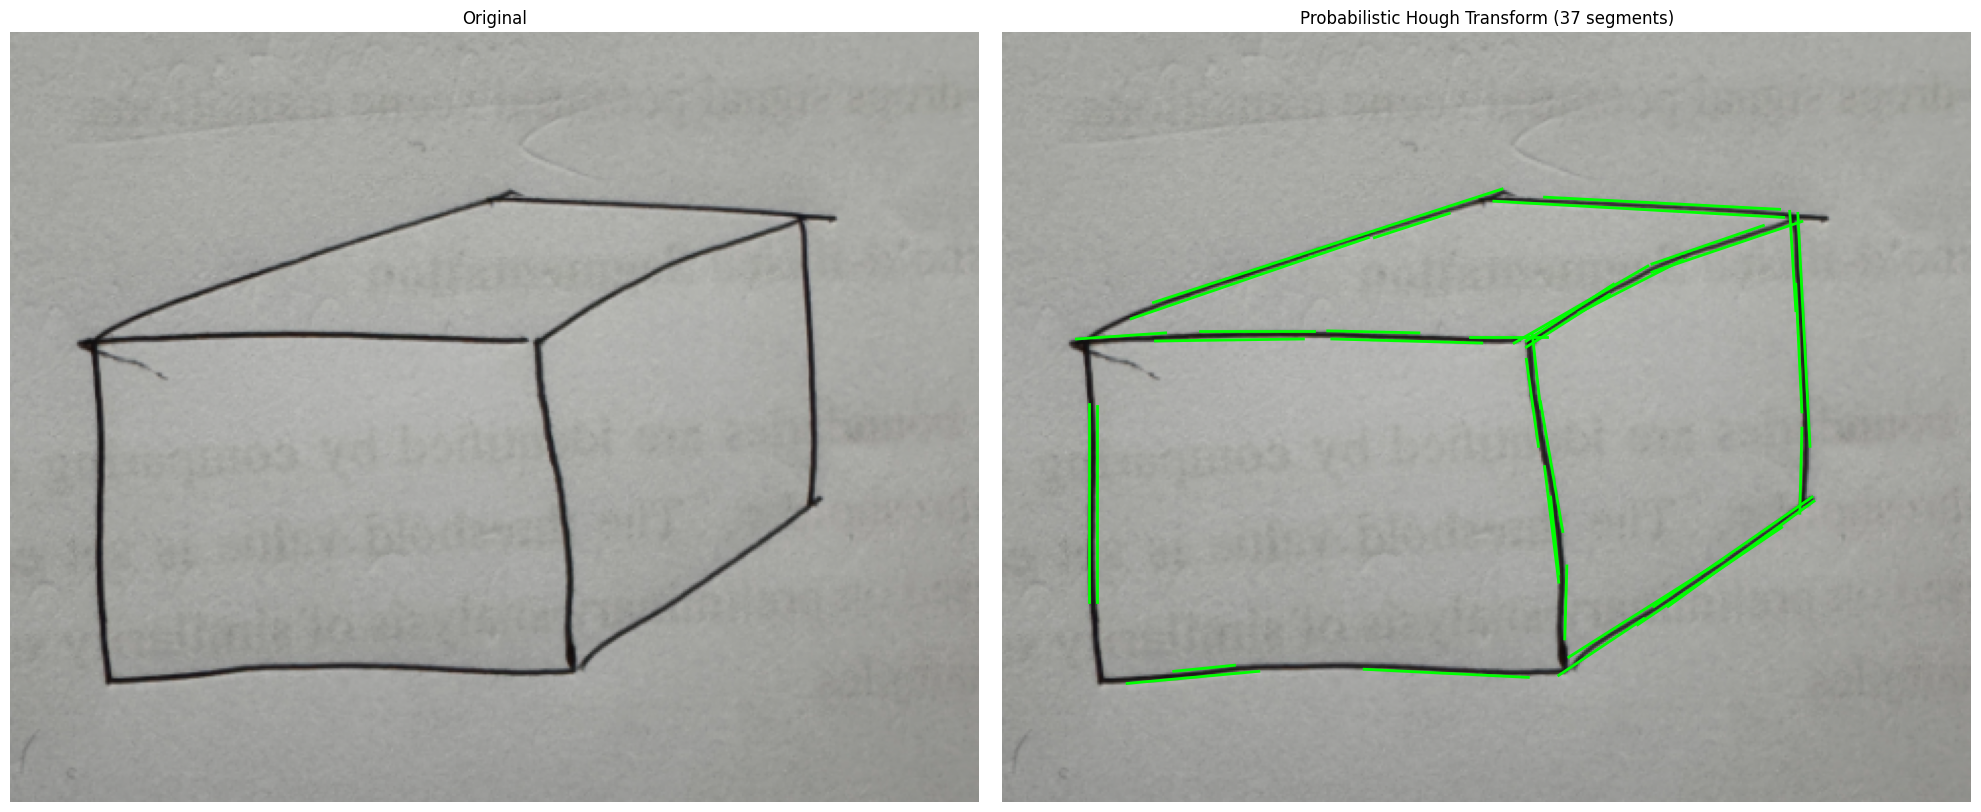

Segments detected: 37


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_color = cv2.imread('cuboid.png')
img_rgb = cv2.cvtColor(img_color, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img_color, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (5, 5), 1.5)
edges = cv2.Canny(blurred, 50, 150)

# Probabilistic Hough Transform returns actual line segments [x1,y1,x2,y2]
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=30,
                        minLineLength=30, maxLineGap=10)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
axes[0].imshow(img_rgb)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(img_rgb)
axes[1].set_title(f'Probabilistic Hough Transform ({len(lines) if lines is not None else 0} segments)')
axes[1].axis('off')

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        axes[1].plot([x1, x2], [y1, y2], color='lime', linewidth=2)

plt.tight_layout()
fig.savefig('result_hough_probabilistic.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Segments detected: {len(lines) if lines is not None else 0}')